In [1]:
# @title
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
  !pip install unsloth
else:
  import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
  xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
  !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
  !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth pillow
  !pip install --no-deps --upgrade "torchao>=0.16.0"
!pip install --no-deps transformers==5.5.0 "tokenizers>=0.22.0,<=0.23.0"
!pip install "huggingface_hub>=1.5.0,<2.0"
!pip install torchcodec
!pip install -q -U deepeval

In [2]:
# @title
from unsloth import FastVisionModel, get_chat_template
from unsloth.trainer import UnslothVisionDataCollator
import io
import gc
import sys
import peft
import glob
import json
import shutil
import base64
import transformers
import pandas as pd
from PIL import Image
from pathlib import Path
from peft import PeftModel
import matplotlib.pyplot as plt
from collections import Counter
from huggingface_hub import login
from trl import SFTTrainer, SFTConfig
from transformers import TextStreamer
from safetensors.torch import load_file
from datetime import datetime, timezone
from google.colab import drive, userdata
from datasets import load_dataset, Dataset
from IPython.display import Markdown, display
from transformers.trainer_utils import get_last_checkpoint
from transformers.generation.streamers import BaseStreamer


from deepeval import evaluate
from deepeval.test_case import LLMTestCase, MLLMImage, SingleTurnParams, LLMTestCaseParams
from deepeval.metrics import GEval, AnswerRelevancyMetric, FaithfulnessMetric


torch._dynamo.config.recompile_limit = 64;

print("Torch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("PEFT:", peft.__version__)
print("CUDA:", torch.cuda.is_available())

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Torch: 2.11.0+cu128
Transformers: 5.5.0
PEFT: 0.20.0
CUDA: True


/tmp/ipykernel_10288/447543625.py:32: DeprecationWarning: 'LLMTestCaseParams' is deprecated and will be removed in a future release. Use 'SingleTurnParams' instead.
  from deepeval.test_case import LLMTestCase, MLLMImage, SingleTurnParams, LLMTestCaseParams


In [3]:
# @title
!rm -rf /root/.cache/huggingface

!rm -rf /root/.cache/pip
!rm -rf /tmp/*

!du -sh /root/.cache/* /tmp/* /content/* 2>/dev/null | sort -hr | head -20

1.3G	/content/drive
56M	/root/.cache/node-gyp
55M	/content/sample_data
1.7M	/content/unsloth_compiled_cache
32K	/root/.cache/matplotlib
12K	/content/__pycache__
8.0K	/root/.cache/antigravity
4.0K	/content/lora_stats_callback.py


In [4]:
MODEL_NAME="Llama-3.2-11B-Vision-Instruct"
BASE_MODEL=f"unsloth/{MODEL_NAME}"
TIMESTAMP=datetime.now(timezone.utc).strftime("%Y-%B-%d_%H:%M")
MAX_LENGTH=1024
RANK=8
MAX_STEPS=60
NUM_TRAIN_EPOCHS=1
LEARNING_RATE=2e-4
RUN_NAME = f"{MODEL_NAME}_{RANK}_{TIMESTAMP}"

In [5]:
# @title
drive.mount('/content/drive')

FT_DIR = Path("/content/drive/MyDrive/Colab Notebooks/fine-tuning")
OUTPUT_DIR = FT_DIR / "radiology" / "outputs" / f'{RANK}'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LOG_DIR = OUTPUT_DIR / "logs"

PLOT_DIR = OUTPUT_DIR / "plots"
ADAPTER_PATH = OUTPUT_DIR / "llama-3-11B-vision_radiology"

training_plots_img = PLOT_DIR / "training_plots.png"
training_plots_pdf = PLOT_DIR / "training_plots.pdf"
training_log_dir = LOG_DIR / "training_log.json"

lora_stats_img = PLOT_DIR / "lora_stats.png"
lora_stats_pdf = PLOT_DIR / "lora_stats.pdf"
gpu_stats_file = LOG_DIR / "gpu_stats.json"

deepeval_img = PLOT_DIR / "deepeval_img.png"
deepeval_pdf = PLOT_DIR / "deepeval_pdf.pdf"
deepeval_xlsx = PLOT_DIR / "deepeval.xlsx"

HF_HUB_DIR = "eneotu/llama-3-11B-vision_radiology"

login(token=userdata.get('HF_TOKEN'))
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# @title
model, tokenizer = FastVisionModel.from_pretrained(
  BASE_MODEL,
  load_in_4bit = True,
  use_gradient_checkpointing = "unsloth",
)

print("\n")
print(f"Base model params: {model.num_parameters()/1e9:.3f} B")
print("\n")

model = FastVisionModel.get_peft_model(
  model,
  finetune_vision_layers     = True,
  finetune_language_layers   = True,
  finetune_attention_modules = True,
  finetune_mlp_modules       = True,

  r = RANK,
  lora_alpha = RANK,
  lora_dropout = 0,
  bias = "none",
  random_state = 3407,
  use_rslora = False,
  loftq_config = None,
  # target_modules = "all-linear",
)

==((====))==  Unsloth 2026.9.7: Fast Mllama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/906 [00:00<?, ?it/s]



Base model params: 10.670 B




In [7]:
dataset = load_dataset("unsloth/Radiology_mini")
train_dataset=dataset["train"]
test_dataset=dataset["test"]

README.md:   0%|          | 0.00/610 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  481MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 79.2MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1978 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/327 [00:00<?, ? examples/s]

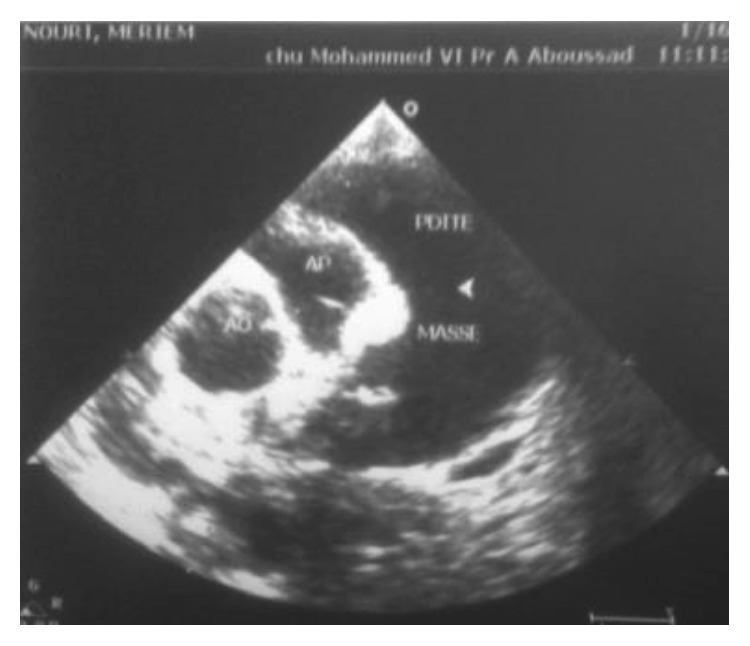

In [8]:
train_dataset[3]["image"]

In [9]:
train_dataset[3]["caption"]

'Pericarditis.'

In [10]:
instruction = "You are an expert radiographer. Describe accurately what you see in this image."

def convert_to_conversation(sample):
    conversation = [
        { "role": "user",
          "content" : [
            {"type" : "text",  "text"  : instruction},
            {"type" : "image", "image" : sample["image"]} ]
        },
        { "role" : "assistant", "content" : [{"type" : "text",  "text"  : sample["caption"]} ]},
    ]
    return { "messages" : conversation }

converted_dataset = [convert_to_conversation(sample) for sample in train_dataset]
converted_dataset = Dataset.from_list(converted_dataset)

converted_test_dataset = [convert_to_conversation(sample) for sample in test_dataset]
converted_test_dataset = Dataset.from_list(converted_test_dataset)

{'messages': [{'content': [{'image': None,
     'text': 'You are an expert radiographer. Describe accurately what you see in this image.',
     'type': 'text'},
    {'image': {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x02\x91\x00\x00\x01\xba\x08\x00\x00\x00\x00u\xc3B\x7f\x00\x01\x00\x00IDATx\x9c\xec\xfd]\xb0n\xdbv\x15\x86\xb5\xd6\xfb\x18s~k\xad}\xce\xb9\x92\xd0\x95@\x12\x89\x10\x12\x10\x84A`\xc7\n\xa1L\x12\'~\x88]\xb1\x1d\xa7B\xd9\xd8\x06\x0b\x17\x98\x80\x130\x18c~\r"De\x08PAN\xe28\xae\x94+\x05E\xcaq*\x0f\xc1\xae\xa4\xe2"N\xb0\xc1D\xc2\x18\x90A\x92\x11\xc6\x06\x81\xac\x9f{\xef9{\xaf\xf5\xcd9Fo-\x0f\xe3[\xfb\xe7\x9cs\xe5T\xe5!z\xb8\xb3\xea\xec\xb3\xfe\xe67\xe7\x1c\xa3\xcf1\xfaOk\xad\xd3\xf8\xd2\xf1\xa5\xe3\'\xd0\x11\xff\xff\xbe\x81/\x1d_:\xde9\xbed\x91_:~b\x1d_\xb2\xc8/\x1d?\xb1\x8e/Y\xe4\x97\x8e\x9fX\xc7\x97,\xf2K\xc7O\xac\xe3K\x16\xf9\xa5\xe3\'\xd6\xf1%\x8b\xfc\xd2\xf1\x13\xebxc\x91\xc2JM\x1a\x90o?\x81 \x00\xb0\x00\xfb9ui\x03\xf0\xfa\xf5\xeb\xc3o\xfe/\xbd\xf9v}q;\xdf~\xfe

In [11]:
# @title ### Markdown streamer
class MarkdownStreamer(BaseStreamer):

    def __init__(self, tokenizer, skip_prompt=True):
        self.tokenizer = tokenizer
        self.skip_prompt = skip_prompt
        self.first_call = True
        self.token_cache = []
        self.decoded_text = ""
        self.display_handle = display(Markdown(""), display_id=True)

    def put(self, value):
        if torch.is_tensor(value):
            value = value.tolist()

        if isinstance(value[0], list):
            value = value[0]

        if self.first_call and self.skip_prompt:
            self.first_call = False
            return

        self.token_cache.extend(value)

        text = self.tokenizer.decode(self.token_cache, skip_special_tokens=True)
        self.decoded_text = text
        self.display_handle.update(Markdown(self.decoded_text))

    def end(self):
        self.display_handle.update(Markdown(self.decoded_text))

In [12]:
# @title ### Base inference

FastVisionModel.for_inference(model)

image = test_dataset[0]["image"]
instruction = "You are an expert radiographer. Describe accurately what you see in this image."

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

text_streamer = MarkdownStreamer(tokenizer)

base_response = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

This ultrasound image appears to depict a 5mm osteochondral defect, specifically located in the intertrochanteric region of the femur.

Upon initial evaluation of the image, an abnormal echogenic focus is visible in the subchondral bone. In terms of appearance, this focus presents with an irregular, cortical discontinuity or step-off and is characterized by an increased reflection of ultrasound. It is noteworthy that this location typically exhibits a high concentration of cancellous bone, which serves as a natural bone bank. This region of bone is commonly implicated in osteochondral lesions due to its location at the site of high-impact stress

/usr/local/lib/python3.13/dist-packages/unsloth/import_fixes.py:2825: UserWarning: 'has_cuda' is deprecated, please use 'torch.backends.cuda.is_built()'
  return original(name)
/usr/local/lib/python3.13/dist-packages/unsloth/import_fixes.py:2825: UserWarning: 'has_cudnn' is deprecated, please use 'torch.backends.cudnn.is_available()'
  return original(name)
/usr/local/lib/python3.13/dist-packages/unsloth/import_fixes.py:2825: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  return original(name)
/usr/local/lib/python3.13/dist-packages/unsloth/import_fixes.py:2825: UserWarning: 'has_mkldnn' is deprecated, please use 'torch.backends.mkldnn.is_available()'
  return original(name)


In [13]:
# @title
%%writefile lora_stats_callback.py

import os
import shutil
from torch.utils.tensorboard import SummaryWriter
from transformers import TrainerCallback


class LoRAStatsCallback(TrainerCallback):

  def __init__(
      self,
      output_dir: str,
      log_every: int = 1,
      adapter_name: str = "default",
      clean_dir: bool = True,
  ):
    self.output_dir = output_dir
    self.log_every = log_every
    self.adapter_name = adapter_name
    self.clean_dir = clean_dir

    self.writer = None
    self._pretrained_norm = None  # cached once — base weights are frozen
    self._param_count_logged = False

  def _iter_lora_modules(self, model):
    for name, module in model.named_modules():
      if hasattr(module, "lora_A") and self.adapter_name in module.lora_A:
        yield name, module

  def _compute_pretrained_norm(self, model):
    """Run once: dequantize (if needed) and norm every frozen base weight

    that has an adapter attached. Expensive — hence cached.
    """
    sq_sum = 0.0
    for _, module in self._iter_lora_modules(model):
      base_layer = module.base_layer
      weight = base_layer.weight
      if hasattr(weight, "quant_state"):
        import bitsandbytes.functional as bnbF

        w = bnbF.dequantize_4bit(weight.data, weight.quant_state)
      else:
        w = weight.data
      sq_sum += w.float().norm().item() ** 2
    return sq_sum**0.5

  def _compute_cheap_stats(self, model):
    """Cheap, every-step: only touches the small A/B factor matrices."""
    total_params = 0
    param_sq_sum = 0.0
    update_sq_sum = 0.0
    max_ratio = 0.0

    for name, module in self._iter_lora_modules(model):
      lora_A = module.lora_A[self.adapter_name].weight
      lora_B = module.lora_B[self.adapter_name].weight
      scaling = module.scaling[self.adapter_name]

      total_params += lora_A.numel() + lora_B.numel()
      param_sq_sum += (
          lora_A.float().norm().item() ** 2 + lora_B.float().norm().item() ** 2
      )

      delta_norm = ((lora_B.float() @ lora_A.float()) * scaling).norm().item()
      update_sq_sum += delta_norm**2

      if self._pretrained_norm is not None:
        max_ratio = max(max_ratio, delta_norm)

    return {
        "adapter_param_count": total_params,
        "adapter_param_norm": param_sq_sum**0.5,
        "adapter_update_norm": update_sq_sum**0.5,
        "max_layer_update_norm": max_ratio,
    }

  def on_train_begin(self, args, state, control, model=None, **kwargs):
    if self.clean_dir and os.path.exists(self.output_dir):
      shutil.rmtree(self.output_dir, ignore_errors=True)

    self.writer = SummaryWriter(log_dir=self.output_dir)

    self._pretrained_norm = self._compute_pretrained_norm(model)
    self.writer.add_scalar(
        "lora/pretrained_weight_norm", self._pretrained_norm, 0
    )

  def on_step_end(self, args, state, control, model=None, **kwargs):
    if state.global_step % self.log_every != 0 or self.writer is None:
      return

    stats = self._compute_cheap_stats(model)

    if not self._param_count_logged:
      self.writer.add_scalar(
          "lora/adapter_param_count",
          stats["adapter_param_count"],
          state.global_step,
      )
      self._param_count_logged = True

    self.writer.add_scalar(
        "lora/adapter_param_norm", stats["adapter_param_norm"], state.global_step
    )
    self.writer.add_scalar(
        "lora/adapter_update_norm",
        stats["adapter_update_norm"],
        state.global_step,
    )
    self.writer.add_scalar(
        "lora/max_layer_update_norm",
        stats["max_layer_update_norm"],
        state.global_step,
    )

    if self._pretrained_norm:
      ratio = stats["adapter_update_norm"] / self._pretrained_norm
      self.writer.add_scalar(
          "lora/update_to_pretrained_ratio", ratio, state.global_step
      )

  def on_train_end(self, args, state, control, **kwargs):
    if self.writer:
      self.writer.flush()
      self.writer.close()

Overwriting lora_stats_callback.py


In [14]:
# @title ### Training

from lora_stats_callback import LoRAStatsCallback


lora_callback = LoRAStatsCallback(output_dir=LOG_DIR, log_every=1)
FastVisionModel.for_training(model)

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer),
    train_dataset = converted_dataset,
    # eval_dataset=converted_val_dataset,
    args = SFTConfig(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        max_steps = MAX_STEPS,
        # num_train_epochs = NUM_TRAIN_EPOCHS,
        learning_rate = LEARNING_RATE,
        warmup_steps = 5,
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = OUTPUT_DIR,
        report_to = "none",     # For Weights and Biases
        run_name = RUN_NAME,

        # logging_first_step=True,
        # eval_strategy="steps",
        # eval_on_start=True,
        # eval_steps=20,
        # save_steps=20,
        # load_best_model_at_end=True,
        # save_strategy = "steps",

        # metric_for_best_model="eval_loss",
        # greater_is_better=False,
        # save_total_limit=2,

        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        max_length = MAX_LENGTH,
    ),
  callbacks=[lora_callback],
)

Unsloth: not enough free memory for dataset tokenization workers (~1GB each); tokenizing in-process.


In [15]:
# @title
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)

gpu_info = {
  "gpu_name": gpu_stats.name,
  "max_memory": max_memory,
  "start_reserved_memory_gb": start_gpu_memory,
}

print(f"GPU: {gpu_info['gpu_name']}")
print(f"Maximum memory: {gpu_info['max_memory']}")
print(f"Reserved memory: {gpu_info['start_reserved_memory_gb']} GB")

GPU: Tesla T4
Maximum memory: 14.563
Reserved memory: 9.299 GB


In [16]:
last_checkpoint = get_last_checkpoint(OUTPUT_DIR)

if last_checkpoint is not None:
  print(f"Resuming training from checkpoint: {last_checkpoint}")
else:
  print("No checkpoint found. Starting fresh training...")

trainer_stats = trainer.train(resume_from_checkpoint=last_checkpoint)

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'bos_token_id': 128000}.


No checkpoint found. Starting fresh training...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,978 | Num Epochs = 1 | Total steps = 60
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 33,587,200 of 10,703,808,035 (0.31% trained)


Step,Training Loss
1,3.559905
2,3.613552
3,3.331396
4,3.149785
5,2.760695
6,2.752709
7,2.418730
8,2.299818
9,1.995726
10,1.613934


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
Unsloth: Will smartly offload gradients to save VRAM!


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/Colab Notebooks/fine-tuning/radiology/outputs/8/checkpoint-60/tokenizer_config.json.


In [17]:
# @title
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)


gpu_info.update({
  "trainer_stats": trainer_stats.metrics['train_runtime'],
  "trainer_stats_min": round(trainer_stats.metrics['train_runtime']/60, 2),
  "used_memory": used_memory,
  "used_memory_for_lora": used_memory_for_lora,
  "used_percentage": used_percentage,
  "lora_percentage": lora_percentage,
})

with open(gpu_stats_file, "w") as f:
  json.dump(gpu_info, f, indent=2)

print(f"GPU stats saved to: {gpu_stats_file}")

print(f"Training time: {gpu_info['trainer_stats_min']} minutes.")
print(f"Peak reserved memory: = {gpu_info['used_memory']} GB.")
print(f"Peak reserved memory for training: = {gpu_info['used_memory_for_lora']} GB.")
print(f"Peak reserved memory % of max memory: = {gpu_info['used_percentage']} %.")
print(f"Peak reserved memory for training % of max memory: = {gpu_info['lora_percentage']} %.")

GPU stats saved to: /content/drive/MyDrive/Colab Notebooks/fine-tuning/radiology/outputs/8/logs/gpu_stats.json
Training time: 32.43 minutes.
Peak reserved memory: = 11.344 GB.
Peak reserved memory for training: = 2.045 GB.
Peak reserved memory % of max memory: = 77.896 %.
Peak reserved memory for training % of max memory: = 14.042 %.


In [18]:
# @title
log_history = trainer.state.log_history

grad_steps = [entry["step"] for entry in log_history if "grad_norm" in entry]
grad_norms = [entry["grad_norm"] for entry in log_history if "grad_norm" in entry]

train_steps = [entry["step"] for entry in log_history if "loss" in entry]
train_loss = [entry["loss"] for entry in log_history if "loss" in entry]

eval_steps = [entry["step"] for entry in log_history if "eval_loss" in entry]
eval_loss = [entry["eval_loss"] for entry in log_history if "eval_loss" in entry]

lr_steps = [entry["step"] for entry in log_history if "learning_rate" in entry]
learning_rates = [entry["learning_rate"] for entry in log_history if "learning_rate" in entry]

log_history_df = pd.DataFrame(log_history)
log_history_df.to_json(training_log_dir, index=False)
log_history_df.head(5)

,loss,grad_norm,learning_rate,epoch,step,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,3.559905,2.389138,0.00000,0.004044,1,NaN,NaN,NaN,NaN,NaN
1,3.613552,2.809372,0.00004,0.008089,2,NaN,NaN,NaN,NaN,NaN
2,3.331396,1.966614,0.00008,0.012133,3,NaN,NaN,NaN,NaN,NaN
3,3.149785,2.522632,0.00012,0.016178,4,NaN,NaN,NaN,NaN,NaN
4,2.760695,1.843787,0.00016,0.020222,5,NaN,NaN,NaN,NaN,NaN


In [19]:
# @title
def publication_style():
  plt.rcParams.update({
    "font.family": "serif",
    "font.serif": [
      "Times New Roman",
      "DejaVu Serif",
      "Computer Modern Roman",
    ],

    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,

    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 4,
    "ytick.major.size": 4,

    "figure.dpi": 150,
    "savefig.dpi": 600,

    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    "axes.spines.top": False,
    "axes.spines.right": False,
  })

def ema(values, alpha=0.15):
  smoothed = [values[0]]
  for v in values[1:]:
    smoothed.append(alpha * v + (1 - alpha) * smoothed[-1])
  return smoothed

publication_style()

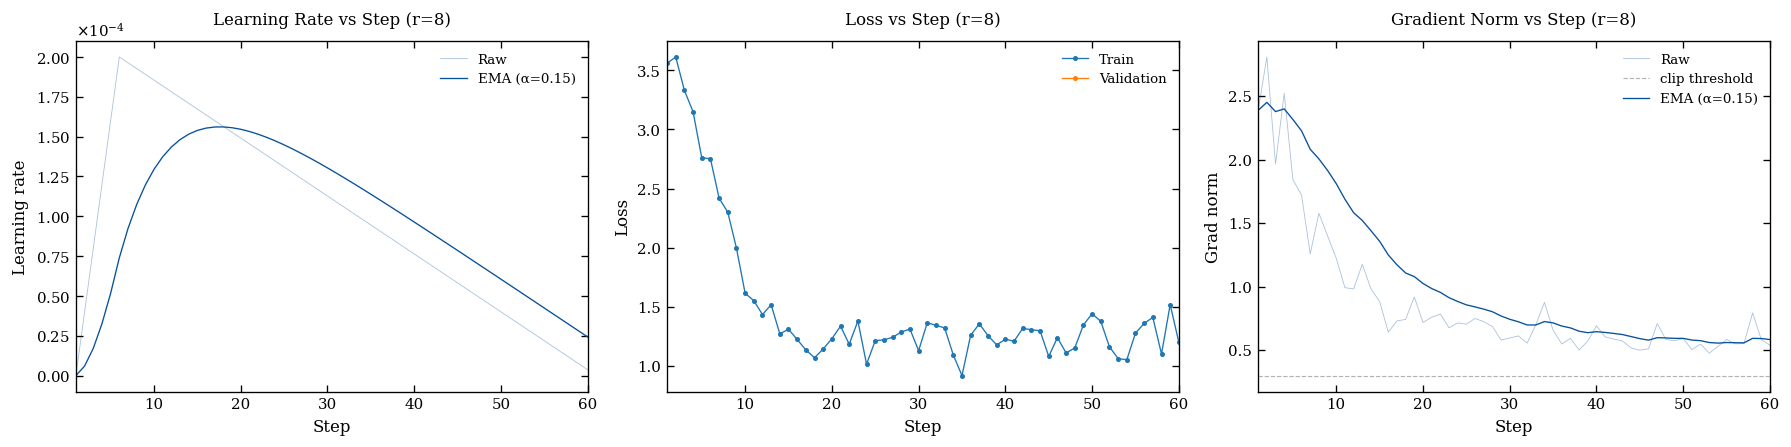

In [20]:
# @title ### Train and validation losses

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), dpi=120)

for ax in axes:
  ax.spines['top'].set_visible(True)
  ax.spines['right'].set_visible(True)
  ax.tick_params(top=True, right=True, direction='in')

ax = axes[0]
ax.plot(lr_steps, learning_rates, color="#08519c", linewidth=0.5, alpha=0.35, label="Raw")
ax.plot(lr_steps, ema(learning_rates), color="#08519c", linewidth=0.8, label="EMA (α=0.15)")

ax.set_xlabel("Step")
ax.set_ylabel("Learning rate")
ax.set_title(f"Learning Rate vs Step (r={RANK})", pad=10)

ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useMathText=True)
ax.set_xlim(min(lr_steps), max(lr_steps))
ax.margins(x=0.01)
ax.legend(frameon=False, loc="upper right")

ax = axes[1]
ax.plot(train_steps, train_loss, linewidth=0.8, label="Train", marker='o', markersize=2,)
ax.plot(eval_steps, eval_loss, linewidth=0.8, label="Validation", marker='o', markersize=2,)

ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title(f"Loss vs Step (r={RANK})", pad=10)
all_steps = train_steps + eval_steps
ax.set_xlim(min(all_steps), max(all_steps))
ax.margins(x=0.01)
ax.legend(frameon=False, loc="upper right")

ax = axes[2]
ax.plot(grad_steps, grad_norms, color="#08519c", linewidth=0.5, alpha=0.35, label="Raw")
ax.axhline(0.3, color="gray", linewidth=0.7, linestyle="--", alpha=0.6, label="clip threshold")
ax.plot(grad_steps, ema(grad_norms), color="#08519c", linewidth=0.8, label="EMA (α=0.15)")

ax.set_xlabel("Step")
ax.set_ylabel("Grad norm")
ax.set_title(f"Gradient Norm vs Step (r={RANK})", pad=10)
ax.set_xlim(min(grad_steps), max(grad_steps))
ax.margins(x=0.01)
ax.legend(frameon=False, loc="upper right")

fig.tight_layout()
fig.savefig(training_plots_img, bbox_inches="tight", dpi=600)
plt.show()

In [21]:
# @title
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

event_files = sorted(LOG_DIR.glob("events.out.tfevents.*"))

print(f"Found {len(event_files)} event file(s)")

metrics = [
  "lora/adapter_param_count",
  "lora/adapter_param_norm",
  "lora/adapter_update_norm",
  "lora/max_layer_update_norm",
]

rows = []

for event_file in event_files:
  ea = EventAccumulator(str(event_file))
  ea.Reload()

  for metric in metrics:
    if metric in ea.Tags()["scalars"]:
      for event in ea.Scalars(metric):
        rows.append({
          "step": event.step,
          "metric": metric.replace("lora/", ""),
          "value": event.value,
        })

lora_df = (
  pd.DataFrame(rows)
  .pivot_table(index="step", columns="metric", values="value", aggfunc="last")
  .reset_index()
  .sort_values("step")
)

lora_df.head(3)

Found 1 event file(s)


metric,step,adapter_param_count,adapter_param_norm,adapter_update_norm,max_layer_update_norm
0,1,33587200.0,37.242992,0.000000,0.000000
1,2,NaN,37.243214,0.074121,0.007106
2,3,NaN,37.247089,0.211172,0.020580


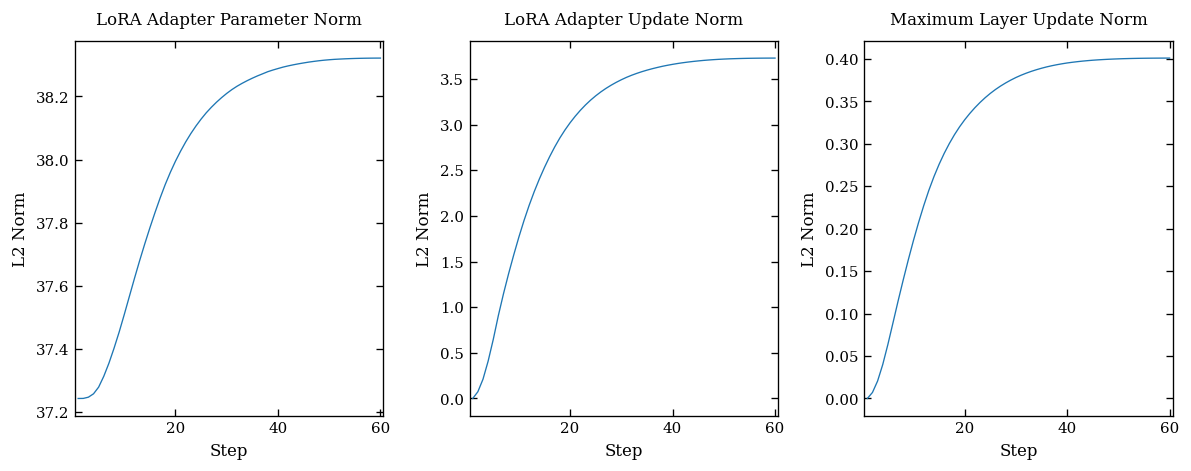

In [22]:
# @title
plot_info = [
  # ("adapter_param_count", "LoRA Adapter Parameter Count", "Parameters"),
  ("adapter_param_norm", "LoRA Adapter Parameter Norm", "L2 Norm"),
  ("adapter_update_norm", "LoRA Adapter Update Norm", "L2 Norm"),
  ("max_layer_update_norm", "Maximum Layer Update Norm", "L2 Norm"),
]

fig, axes = plt.subplots(1, 3, figsize=(10, 4), dpi=120,)
axes = axes.ravel()

for ax, (metric, title, ylabel) in zip(axes, plot_info):

  if metric not in lora_df.columns:
    ax.set_visible(False)
    continue

  ax.plot(lora_df["step"], lora_df[metric], linewidth=0.8,)
  ax.set_xlabel("Step")
  ax.set_ylabel(ylabel)
  ax.set_title(title, pad=10)

  ax.spines['top'].set_visible(True)
  ax.spines['right'].set_visible(True)
  ax.tick_params(top=True, right=True, direction='in')
  # ax.grid(axis="y", alpha=0.3)
  ax.margins(x=0.01)

fig.tight_layout()
fig.savefig(lora_stats_pdf, bbox_inches="tight")
fig.savefig(lora_stats_img, bbox_inches="tight", dpi=600)

plt.show()

In [29]:
# @title ### Save fine-tuned model

# model.save_pretrained(ADAPTER_PATH)
# tokenizer.save_pretrained(ADAPTER_PATH)

model.push_to_hub(HF_HUB_DIR, token=userdata.get('HF_TOKEN'))
tokenizer.push_to_hub(HF_HUB_DIR, token=userdata.get('HF_TOKEN'))

README.md:   0%|          | 0.00/607 [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   0%|          |  131kB /  135MB            

Saved model to https://huggingface.co/eneotu/llama-3-11B-vision_radiology


Unsloth: Restored added_tokens_decoder metadata in /tmp/tmpfuq3o8zc/tokenizer_config.json.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpfuq3o8zc/tokenizer.json:  83%|########2 | 14.3MB / 17.2MB            

In [30]:
# @title ### Fine-tuned inference

FastVisionModel.for_inference(model)

SAMPLE_INDEX=5
image = test_dataset[SAMPLE_INDEX]["image"]
instruction = "You are an expert radiographer. Describe accurately what you see in this image."

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

text_streamer = MarkdownStreamer(tokenizer)
ft_response = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

Digital panoramic radiograph of the maxillary incisors in a 20-year-old female. Radiopaque radiolucency surrounds the apex of the maxillary left central incisor. Radiograph after endodontic treatment of a maxillary left central incisor.

In [31]:
test_dataset[SAMPLE_INDEX]["caption"]

'X-ray shows periapical radiolucency'